# Repaso final: Turismo internacional

Este repaso usa un contexto distinto al examen, pero practica los mismos patrones: recorrer datos, crear una función, filtrar, agrupar, ordenar, graficar e interpretar.

Trabaje con `turismo_internacional_repaso.csv` sin modificarlo. **Antes de iniciar, guarde una copia como `Apellido_Nombre_Repaso_Final.ipynb`.**

Distribución inequívoca: Parte 1, Parte 2, Parte 3, Parte 4, Parte 5 y cierre.

## Parte 1 — Preparación

**TODO 1.1 — Entrada, proceso y salida**

Escriba aquí una frase que identifique: (1) la entrada —el archivo y sus datos—, (2) el proceso —las operaciones de análisis— y (3) la salida —tablas, gráficos e interpretaciones.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

archivo = 'turismo_internacional_repaso.csv'
df = pd.read_csv(archivo)
df.head()

,pais,anio,llegadas_miles
0,Belize,2012,1028.0
1,Belize,2013,1022.0
2,Belize,2014,1289.0
3,Belize,2015,1299.0
4,Belize,2016,1391.0


In [4]:
print("Dimensiones: ", df.shape)
print("Tipado: \n", df.info)

print("valores nulos: \n", df.isnull().sum())


Dimensiones:  (94, 3)
Tipado: 
 <bound method DataFrame.info of       pais  anio  llegadas_miles
0   Belize  2012          1028.0
1   Belize  2013          1022.0
2   Belize  2014          1289.0
3   Belize  2015          1299.0
4   Belize  2016          1391.0
..     ...   ...             ...
89    Perú  2018          4419.0
90    Perú  2019          4372.0
91    Perú  2020           897.0
92    Perú  2021           444.0
93    Perú  2022          2010.0

[94 rows x 3 columns]>
valores nulos: 
 pais              0
anio              0
llegadas_miles    0
dtype: int64


## Parte 2 — Python base: registros y función

1. Muestre `shape`, `dtypes` y una descripción breve de cada columna.
2. Convierta el DataFrame en una lista de diccionarios llamada `registros`.
3. Con un ciclo y una condición, cuente los registros cuya cantidad de llegadas es mayor a 3 000 miles.
4. Complete `resumen_pais`. Debe devolver un diccionario con país, cantidad de anios, total y promedio de llegadas para el país solicitado. Si no existe, debe devolver `None`.

In [ ]:
# Escriba su solución aquí.
registros = df.to_dict(orient='records')  # Convertir el DataFrame a una lista de diccionarios
#print(registros)
contador = 0

for registro in registros:
    if registro['llegadas_miles'] > 3000:
        contador += 1

print(f"Cantidad de registros con llegadas mayores a 3000: {contador}")

Cantidad de registros con llegadas mayores a 3000: 26


In [ ]:
def resumen_pais(registros, pais):
    # Recorra los registros y acumule solo los del país indicado.
    # Debe devolver un diccionario con país, cantidad de anios, total y promedio de llegadas para el país solicitado. Si no existe, debe devolver None.
    registros_pais = [r for r in registros if r['pais'] == pais]
    if registros_pais: 
        total_llegadas = sum(r['llegadas_miles'] for r in registros_pais)
        cantidad_anios = len(registros_pais)
        promedio_llegadas = total_llegadas / cantidad_anios
        return {
            'pais': pais,
            'cantidad_anios': cantidad_anios,
            'total_llegadas': total_llegadas,
            'promedio_llegadas': promedio_llegadas
        }
    
pais = input("Ingrese el nombre del pais: ").title()        
resultado = resumen_pais(registros, pais)
print(resultado)

{'pais': 'Costa Rica', 'cantidad_años': 9, 'total_llegadas': 25102.5, 'promedio_llegadas': 2789.1666666666665}


## Parte 3 — Pandas: Análisis Comparativo y de Impacto

Con el nuevo conjunto de datos, podemos realizar un análisis regional más profundo.

1.  **Ranking de Líderes Regionales:**
    *   Calcula el **total de llegadas por país** para todo el período (2012-2022).
    *   Genera un ranking ordenado de mayor a menor para identificar los 3 países con más llegadas en la región.

2.  **Análisis de Impacto (COVID-19):**
    *   Crea un nuevo DataFrame que contenga únicamente los datos de 2019 y 2020.
    *   A partir de él, calcula la **caída porcentual** en el turismo para cada país. La fórmula es `((llegadas_2019 - llegadas_2020) / llegadas_2019) * 100`.
    *   Muestra una tabla con los resultados, ordenada de mayor a menor caída porcentual, para ver qué países fueron los más afectados.

In [34]:
# Separar los datos de 2019 y 2020 en DataFrames independientes
df_2019 = df[df['anio'] == 2019][['pais', 'llegadas_miles']].rename(
    columns={'llegadas_miles': 'llegadas_2019'}
)
df_2020 = df[df['anio'] == 2020][['pais', 'llegadas_miles']].rename(
    columns={'llegadas_miles': 'llegadas_2020'}
)

# Unir ambos años alineados por el nombre del país
df_impacto = pd.merge(df_2019, df_2020, on='pais')

# Aplicar fórmula de caída porcentual
df_impacto['caida_porcentual'] = (
    (df_impacto['llegadas_2019'] - df_impacto['llegadas_2020'])
    / df_impacto['llegadas_2019']
) * 100

# Seleccionar columnas y ordenar de mayor a menor caída
resultado_caida = df_impacto[['pais', 'caida_porcentual']].sort_values(
    by='caida_porcentual', ascending=False
)

print(resultado_caida)

# Recuerde usar paréntesis para combinar condiciones y nlargest(5, 'llegadas_miles').

          pais  caida_porcentual
9         Perú         79.483074
3    Guatemala         76.796875
7       Panama         74.057739
2  El Salvador         73.209549
4     Honduras         71.101512
0       Belize         70.908005
8     Colombia         67.705448
6    Nicaragua         67.422680
1   Costa Rica         65.938800
5       Mexico         47.510420


## Parte 4 — Visualización Comparativa e Interpretación

Ahora, vamos a contar la historia de los datos con visualizaciones más ricas.

1.  **Gráfico de Líneas Comparativo:**
    *   Construye una gráfica de líneas que compare la evolución de llegadas para **todos los países** a lo largo de los años.
    *   **Interpretación:** Tu análisis debe mencionar: (1) La escala de México en comparación con los demás, (2) la tendencia general antes de 2020, y (3) el impacto visible de la pandemia en 2020 en todo el grupo.

2.  **Gráfico de Barras del Impacto (COVID-19):**
    *   Crea un **gráfico de barras horizontales** que muestre la **caída porcentual** por país que calculaste en la Parte 3.
    *   **Interpretación:** Explica qué países sufrieron el mayor y menor impacto relativo según la gráfica.

3.  **Gráfico de Barras de Recuperación:**
    *   Crea un **gráfico de barras agrupadas** que compare las llegadas de **2019 (pre-pandemia)** con las de **2022 (recuperación)** para cada país.
    *   **Interpretación:** Describe qué países parecen haberse recuperado más rápido y si alguno ha superado sus niveles pre-pandemia.

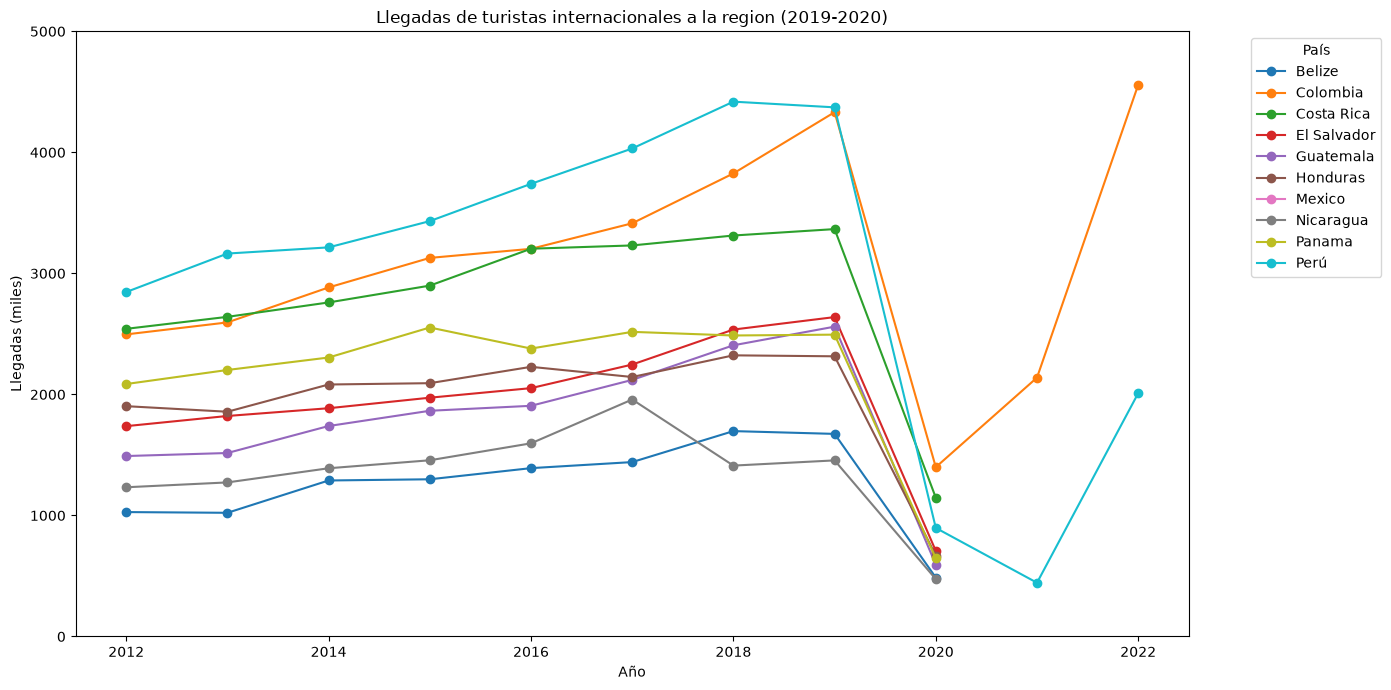

In [42]:
# 1. Grafico de lineas comparativo
plt.figure(figsize=(14, 7))

for pais, datos_pais in df.groupby('pais'):
    #plt.plot(datos_pais['anio'], datos_pais['llegadas_miles'], marker='o', label=pais)
    eje_x = datos_pais['anio']
    eje_y = datos_pais['llegadas_miles']
    plt.plot(eje_x, eje_y, marker='o', label=pais)
    
plt.title('Llegadas de turistas internacionales a la region (2019-2020)')
plt.xlabel('Año')
plt.ylabel('Llegadas (miles)')
plt.ylim(0, 5000)
plt.legend(title='País', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

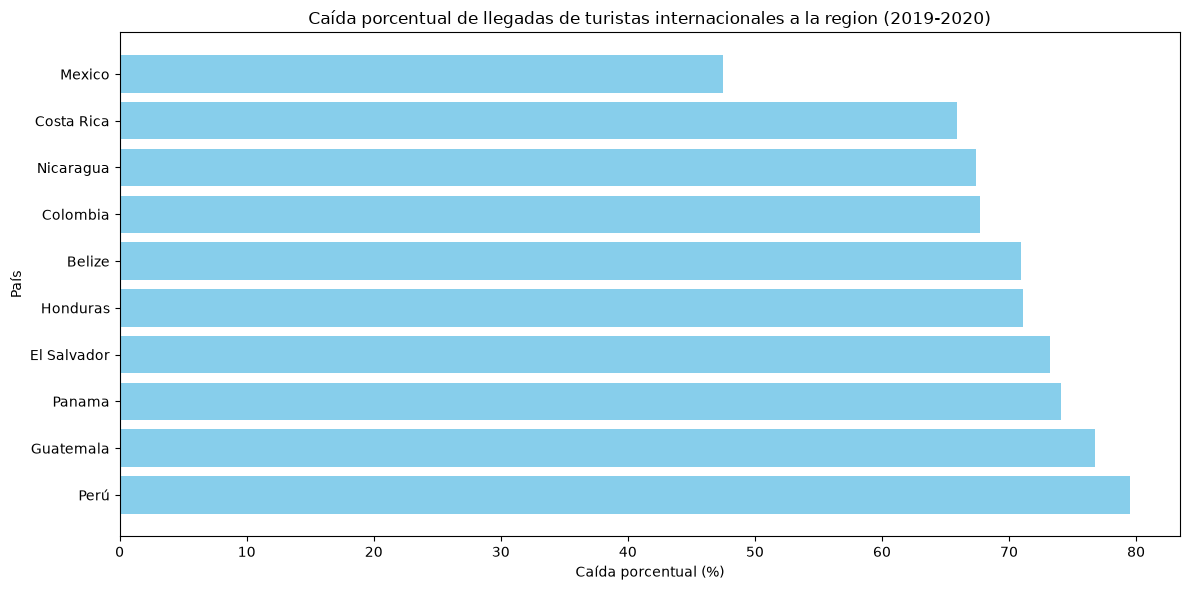

In [45]:
# Crea un gráfico de barras horizontales que muestre la caída porcentual por país que calculaste en la Parte 3 (resultado_caida).
plt.figure(figsize=(12, 6))

plt.barh(resultado_caida['pais'], resultado_caida['caida_porcentual'], color='skyblue')
plt.title('Caída porcentual de llegadas de turistas internacionales a la region (2019-2020)')
plt.xlabel('Caída porcentual (%)')
plt.ylabel('País')
plt.tight_layout()
plt.show()


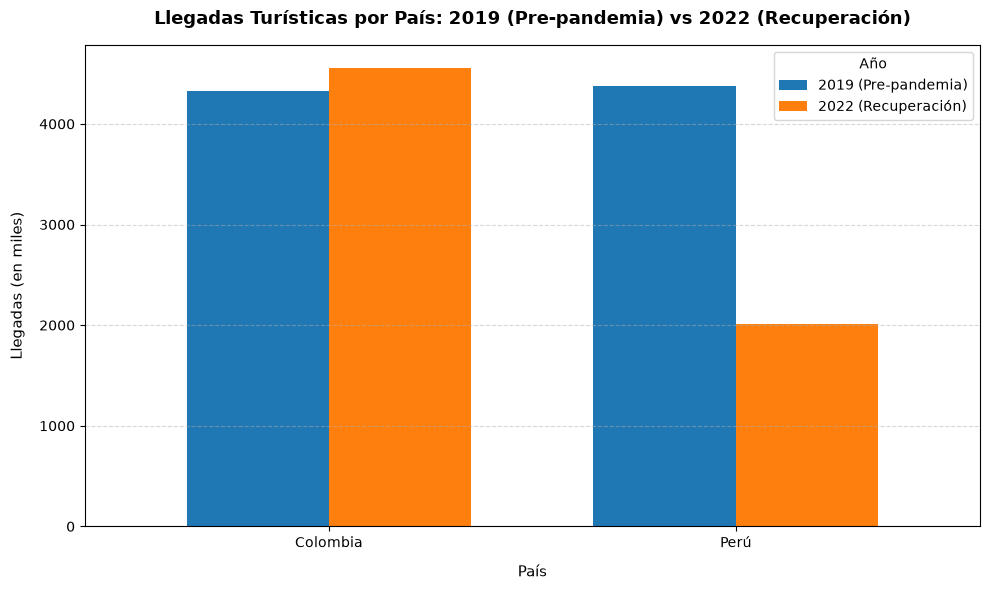

In [62]:
# Crea un gráfico de barras agrupadas que compare las llegadas de 2019 (pre-pandemia) con las de 2022 (recuperación) para CADA PAIS.
df_2019 = df[df['anio'] == 2019][['pais', 'llegadas_miles']].rename(
    columns={'llegadas_miles': 'llegadas_2019'})
# En el 2022, solo hay dos paises que se recogieron datos, por lo que se debe poner 0 para los paises que no tienen datos en 2022. Esto se puede hacer usando un merge con un DataFrame que contenga todos los paises.
df_2022 = df[df['anio'] == 2022][['pais', 'llegadas_miles']].rename(
    columns={'llegadas_miles': 'llegadas_2022'})
#recuperacion = pd.merge(df_2019, df_2022, on='pais', how='left').fillna(0)
recuperacion = pd.merge(df_2019, df_2022, on='pais')
# Crear el grafico de barras agrupadas
# Crear la figura y los ejes
fig, ax = plt.subplots(figsize=(10, 6))

# Graficar las barras agrupadas desde el DataFrame 'recuperacion'
recuperacion.plot(
    x='pais',
    y=['llegadas_2019', 'llegadas_2022'],
    kind='bar',
    ax=ax,
    width=0.7,
    color=['#1f77b4', '#ff7f0e']  # Azul para 2019, Naranja para 2022
)

# Personalización del gráfico
plt.title('Llegadas Turísticas por País: 2019 (Pre-pandemia) vs 2022 (Recuperación)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('País', fontsize=11, labelpad=10)
plt.ylabel('Llegadas (en miles)', fontsize=11, labelpad=10)
plt.legend(['2019 (Pre-pandemia)', '2022 (Recuperación)'], title='Año')
plt.xticks(rotation=0)  # Rotación de etiquetas de los países (0° o 45° si son muchos)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



In [61]:
display(recuperacion)

,pais,llegadas_2019,llegadas_2022
0,Belize,1674.0,0.0
1,Costa Rica,3366.0,0.0
2,El Salvador,2639.0,0.0
3,Guatemala,2560.0,0.0
4,Honduras,2315.0,0.0
5,Mexico,97406.0,0.0
6,Nicaragua,1455.0,0.0
7,Panama,2494.0,0.0
8,Colombia,4332.0,4558.0
9,Perú,4372.0,2010.0


,2019,2022
pais,,
Colombia,4332.0,4558.0
Perú,4372.0,2010.0


<Axes: xlabel='pais'>

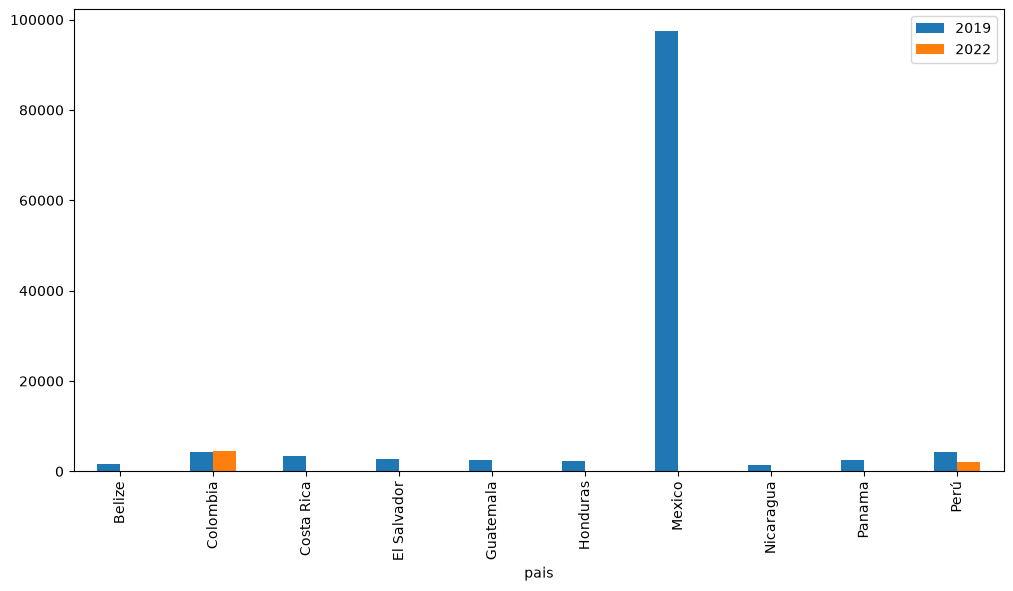

In [64]:
df_2019 = df[df['anio']==2019].set_index('pais')['llegadas_miles']
df_2022 = df[df['anio']==2022].set_index('pais')['llegadas_miles']

df_recuperacion = pd.DataFrame(
    {
        '2019': df_2019,
        '2022': df_2022
    }
)
display(df_recuperacion.dropna())
df_recuperacion.plot(kind='bar', figsize=(12, 6))

In [4]:
# Escriba aquí las tres gráficas.
# Use plt.show() al finalizar cada una e incluya una interpretación escrita.

## Parte 5 — Mini-simulacro individual

Sin consultar soluciones, resuelva lo siguiente:

1. Convierta el DataFrame a una lista de diccionarios y cree una función que recorra los registros, use una condición y devuelva el total de llegadas de un país indicado; devuelva `None` si no existe.
2. Use un filtro compuesto para seleccionar registros de 2019 o posteriores con más de 3 000 miles de llegadas.
3. Cree un resumen con `groupby(...).agg(...)` y seleccione con `nlargest(5, 'llegadas_miles')` las cinco observaciones de mayor valor.
4. Elabore una gráfica de barras horizontales del ranking y redacte un hallazgo numérico verificable, una interpretación y una limitación del dataset.

**Autoevaluación:** ¿su respuesta incluye lista de diccionarios, ciclo, condición y función?, ¿sus filtros usan la columna correcta?, ¿aplicó `groupby(...).agg(...)` y `nlargest(5, ...)`?, ¿sus gráficos son legibles?, ¿sus afirmaciones tienen evidencia y una limitación?

In [5]:
# Resuelva aquí el mini-simulacro.
# Incluya la función, el filtro compuesto, groupby(...).agg(...), nlargest(5, ...)
# y su interpretación con evidencia y limitación.

## Cierre y autoevaluación

Compare su trabajo con la lista de autoevaluación de la Parte 5. Entregue el notebook con su nombre, código ejecutado, tres gráficos, interpretaciones con evidencia y una limitación. La retroalimentación docente se realiza después del intento individual.